In [1]:
!pip install scikit-learn pandas numpy joblib matplotlib --quiet

import pandas as pd
import numpy as np
import gc
import joblib
import warnings
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
print("Imports successful")

Imports successful


In [2]:
uploaded = files.upload()

Saving master_dataset.zip to master_dataset.zip


In [3]:
!unzip /content/master_dataset.zip

Archive:  /content/master_dataset.zip
  inflating: master_dataset.csv      


In [8]:
print("Loading dataset...")
master_df = pd.read_csv("master_dataset.csv")

label_col    = "disease"
feature_cols = [c for c in master_df.columns if c != label_col]

y_raw = master_df[label_col].values
X_raw = master_df[feature_cols].values.astype(np.float32)

del master_df
gc.collect()

print(f"X: {X_raw.shape} | Classes: {len(np.unique(y_raw))}")

Loading dataset...
X: (190622, 1756) | Classes: 1117


In [9]:
le = LabelEncoder()
y  = le.fit_transform(y_raw)

joblib.dump(le,           "label_encoder.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")

print(f"{len(le.classes_)} disease classes encoded")
print("label_encoder.pkl and feature_cols.pkl saved")

1117 disease classes encoded
label_encoder.pkl and feature_cols.pkl saved


In [10]:
# Remove diseases with fewer than 6 samples (can't stratify across 3 splits)
counts       = pd.Series(y).value_counts()
valid_classes = counts[counts >= 6].index
mask          = np.isin(y, valid_classes)
X_raw, y      = X_raw[mask], y[mask]
print(f"Rows after rare-class filter: {len(y)}")

# ── 70 / 15 / 15 Stratified Split ──
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y,
    test_size    = 0.30,
    random_state = 42,
    stratify     = y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size    = 0.50,   # 50% of 30% = 15% of total
    random_state = 42,
    stratify     = y_temp
)

del X_raw, y_temp
gc.collect()

# Save splits — ALL other notebooks load this exact file
joblib.dump({
    "X_train": X_train, "X_val": X_val, "X_test": X_test,
    "y_train": y_train, "y_val": y_val, "y_test": y_test
}, "splits.pkl")

print(f"Train:      {X_train.shape[0]} rows")
print(f"Validation: {X_val.shape[0]} rows")
print(f"Test:       {X_test.shape[0]} rows")
print("splits.pkl saved")

Rows after rare-class filter: 189810
Train:      132867 rows
Validation: 28471 rows
Test:       28472 rows
splits.pkl saved


In [11]:
class_weights_array = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(y_train),
    y            = y_train
)
class_weight_dict = dict(enumerate(class_weights_array))
print(f"Class weights computed for {len(class_weight_dict)} classes")

Class weights computed for 674 classes


In [12]:
rf_model = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 20,
    min_samples_leaf = 2,
    max_features     = "sqrt",
    class_weight     = "balanced",
    random_state     = 42,
    n_jobs           = -1
)

print("Training Random Forest...")
rf_model.fit(X_train, y_train)

joblib.dump(rf_model, "rf_model.pkl")
print("rf_model.pkl saved")

Training Random Forest...
rf_model.pkl saved


In [15]:
y_val_pred = rf_model.predict(X_val)
val_acc    = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_acc*100:.2f}%")

# Train accuracy for overfit gap check
train_acc = accuracy_score(y_train, rf_model.predict(X_train))
gap       = train_acc - val_acc
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Val Accuracy   : {val_acc*100:.2f}%")
print(f"Gap            : {gap*100:.2f}% {'- OK' if gap < 0.10 else '- Check regularization'}")

Validation Accuracy: 77.32%
Train Accuracy : 79.80%
Val Accuracy   : 77.32%
Gap            : 2.48% - OK


In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_model, X_train, y_train,
    cv      = skf,
    scoring = "accuracy",
    n_jobs  = -1
)

print(f"CV Scores : {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean      : {cv_scores.mean()*100:.2f}%")
print(f"Std Dev   : {cv_scores.std()*100:.2f}% {'- Stable' if cv_scores.std() < 0.02 else '- Check variance'}")

CV Scores : ['0.7766', '0.7599', '0.7588', '0.7621', '0.7650']
Mean      : 76.45%
Std Dev   : 0.64% - Stable


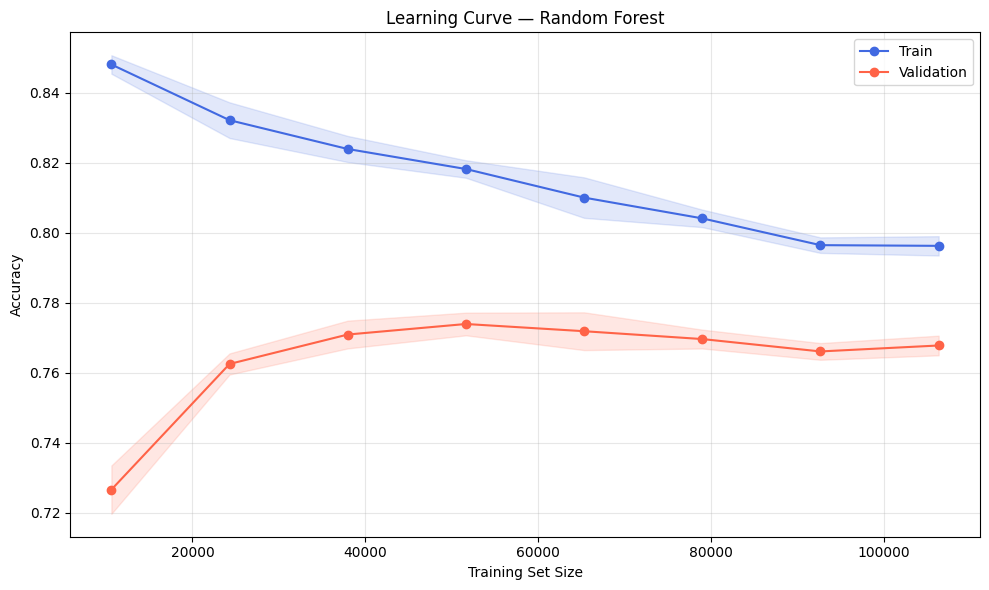

Learning curve saved


In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train, y_train,
    cv           = 5,
    scoring      = "accuracy",
    train_sizes  = np.linspace(0.1, 1.0, 8),
    n_jobs       = -1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", color="royalblue", label="Train")
plt.fill_between(train_sizes,
    train_scores.mean(axis=1) - train_scores.std(axis=1),
    train_scores.mean(axis=1) + train_scores.std(axis=1),
    alpha=0.15, color="royalblue")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", color="tomato", label="Validation")
plt.fill_between(train_sizes,
    val_scores.mean(axis=1) - val_scores.std(axis=1),
    val_scores.mean(axis=1) + val_scores.std(axis=1),
    alpha=0.15, color="tomato")
plt.title("Learning Curve — Random Forest")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rf_learning_curve.png", dpi=100)
plt.show()
print("Learning curve saved")

In [19]:
files.download("splits.pkl")
files.download("label_encoder.pkl")
files.download("feature_cols.pkl")
files.download("rf_model.pkl")
files.download("rf_learning_curve.png")
print("All Files Downloaded")
print("Random Forest - Done")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All Files Downloaded
Random Forest - Done
